In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# HW2 Part I
# Import data, calculate price index, merge, convert
# nominal income to real income, and plot both series
# with fitted trend lines
# =========================================================

# -----------------------------
# 1. Import data into Python
# -----------------------------
income_path = "/mnt/data/MEHOINUSA646N.csv"
cpi_path = "/mnt/data/cpi_annual.csv"

income = pd.read_csv(income_path)
cpi = pd.read_csv(cpi_path)

# -----------------------------
# 2. Clean Household Income data
# -----------------------------
income["observation_date"] = pd.to_datetime(income["observation_date"])
income["year"] = income["observation_date"].dt.year
income = income.rename(columns={"MEHOINUSA646N": "nominal_income"})
income = income[["year", "nominal_income"]].copy()

# -----------------------------
# 3. Clean CPI data
# -----------------------------
# Keep only the needed columns
cpi = cpi[["observation_date", "CPIAUCSL"]].copy()

# Convert date column to datetime
cpi["observation_date"] = pd.to_datetime(cpi["observation_date"], format="%m/%d/%y")

# Extract year
cpi["year"] = cpi["observation_date"].dt.year

# Rename CPI column
cpi = cpi.rename(columns={"CPIAUCSL": "cpi"})
cpi = cpi[["year", "cpi"]].copy()

# -----------------------------
# 4. Calculate the price index
# -----------------------------
# Use the first household income year as the base year
base_year = income["year"].min()

# Keep CPI years that match the household income sample
cpi = cpi[(cpi["year"] >= income["year"].min()) & (cpi["year"] <= income["year"].max())].copy()

# CPI in the base year
base_cpi = cpi.loc[cpi["year"] == base_year, "cpi"].iloc[0]

# Price index with base year = 100
cpi["price_index"] = (cpi["cpi"] / base_cpi) * 100

# -----------------------------
# 5. Merge CPI with Household Income
# -----------------------------
df = pd.merge(income, cpi, on="year", how="inner")
df = df.sort_values("year").reset_index(drop=True)

# -----------------------------
# 6. Convert Nominal Income to Real Income
# -----------------------------
# Real income in base-year dollars
df["real_income"] = df["nominal_income"] / (df["price_index"] / 100)

# -----------------------------
# 7. Create fitted trend lines
# -----------------------------
x = df["year"].values

# Linear trend for nominal income
nominal_coeffs = np.polyfit(x, df["nominal_income"], 1)
nominal_trend = np.polyval(nominal_coeffs, x)

# Linear trend for real income
real_coeffs = np.polyfit(x, df["real_income"], 1)
real_trend = np.polyval(real_coeffs, x)

# -----------------------------
# 8. Print tables/results
# -----------------------------
print("Base year used for price index:", base_year)
print("Base CPI:", round(base_cpi, 3))

print("\nMerged dataset:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

# -----------------------------
# 9. Generate the plot
#    - nominal and real income on same figure
#    - fitted trend line for both series
# -----------------------------
plt.figure(figsize=(12, 7))

plt.plot(df["year"], df["nominal_income"], linewidth=2, label="Nominal Household Income")
plt.plot(df["year"], df["real_income"], linewidth=2, label=f"Real Household Income ({base_year} dollars)")

# Add fitted trend lines
plt.plot(df["year"], nominal_trend, linestyle="--", linewidth=2, label="Nominal Trend Line")
plt.plot(df["year"], real_trend, linestyle="--", linewidth=2, label="Real Trend Line")

plt.title("U.S. Median Household Income: Nominal vs Real")
plt.xlabel("Year")
plt.ylabel("Income (Dollars)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 10. Optional: save merged file
# -----------------------------
df.to_csv("hw2_part1_merged_income_cpi.csv", index=False)
print('\nSaved file: hw2_part1_merged_income_cpi.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/MEHOINUSA646N.csv'

Base year used for price index: 1984
Base CPI: 103.933

Merged dataset:
   year  nominal_income      cpi  price_index   real_income
0  1984           22420  103.933   100.000000  22420.000000
1  1985           23620  107.600   103.528235  22815.032156
2  1986           24900  109.692   105.541070  23592.711410
3  1987           26060  113.617   109.317541  23838.809157
4  1988           27230  118.275   113.799275  23928.096301

Last 5 rows:
    year  nominal_income      cpi  price_index   real_income
35  2019           68700  255.653   245.978659  27929.252150
36  2020           68010  258.846   249.050831  27307.678427
37  2021           70780  270.966   260.712190  27148.711425
38  2022           74580  292.621   281.547728  26489.292088
39  2023           80610  304.701   293.170600  27495.935786


/var/folders/yk/fy393lbs5kscdjv4m1qwx9_r0000gn/T/ipykernel_2582/1821703661.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cpi["observation_date"] = pd.to_datetime(cpi["observation_date"])


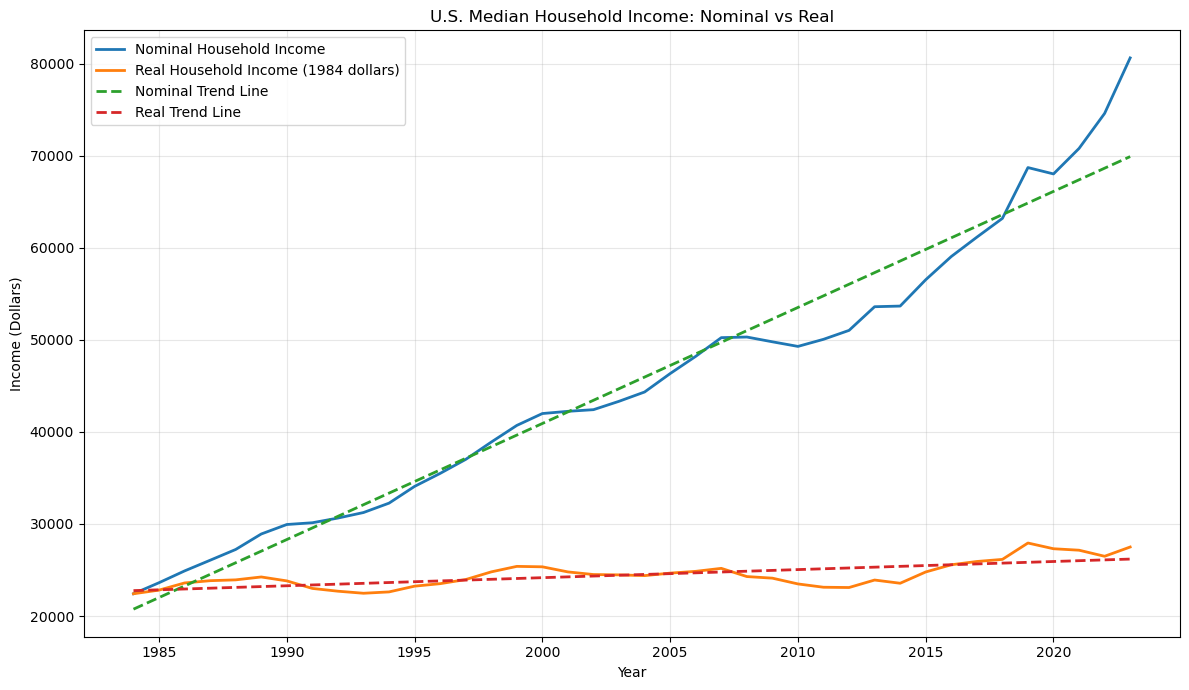


Saved file: /Users/anxinyi/Documents/GitHub/AAE625_2026/hw2_part1_merged_income_cpi.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# HW2 Part I
# Import data, calculate price index, merge, convert
# nominal income to real income, and plot both series
# with fitted trend lines
# =========================================================

# 1. Import data into Python using your exact file paths
income_path = "/Users/anxinyi/Documents/GitHub/AAE625_2026/MEHOINUSA646N.csv"
cpi_path = "/Users/anxinyi/Documents/GitHub/AAE625_2026/cpi_annual.csv"

income = pd.read_csv(income_path)
cpi = pd.read_csv(cpi_path)

# 2. Clean household income data
income["observation_date"] = pd.to_datetime(income["observation_date"])
income["year"] = income["observation_date"].dt.year
income = income.rename(columns={"MEHOINUSA646N": "nominal_income"})
income = income[["year", "nominal_income"]].copy()

# 3. Clean CPI data
cpi = cpi[["observation_date", "CPIAUCSL"]].copy()
cpi["observation_date"] = pd.to_datetime(cpi["observation_date"])
cpi["year"] = cpi["observation_date"].dt.year
cpi = cpi.rename(columns={"CPIAUCSL": "cpi"})
cpi = cpi[["year", "cpi"]].copy()

# 4. Calculate the price index
# Use the first year in the income data as the base year
base_year = income["year"].min()

# Keep only matching years
cpi = cpi[(cpi["year"] >= income["year"].min()) & (cpi["year"] <= income["year"].max())].copy()

# CPI in the base year
base_cpi = cpi.loc[cpi["year"] == base_year, "cpi"].iloc[0]

# Price index where base year = 100
cpi["price_index"] = (cpi["cpi"] / base_cpi) * 100

# 5. Merge CPI data with household income
df = pd.merge(income, cpi, on="year", how="inner")
df = df.sort_values("year").reset_index(drop=True)

# 6. Convert nominal income to real income
# Real income in base-year dollars
df["real_income"] = df["nominal_income"] / (df["price_index"] / 100)

# 7. Create fitted trend lines
x = df["year"].values

nominal_coeffs = np.polyfit(x, df["nominal_income"], 1)
nominal_trend = np.polyval(nominal_coeffs, x)

real_coeffs = np.polyfit(x, df["real_income"], 1)
real_trend = np.polyval(real_coeffs, x)

# 8. Print results
print("Base year used for price index:", base_year)
print("Base CPI:", round(base_cpi, 3))

print("\nMerged dataset:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

# 9. Plot nominal and real income with fitted trend lines
plt.figure(figsize=(12, 7))

plt.plot(df["year"], df["nominal_income"], linewidth=2, label="Nominal Household Income")
plt.plot(df["year"], df["real_income"], linewidth=2, label=f"Real Household Income ({base_year} dollars)")

plt.plot(df["year"], nominal_trend, linestyle="--", linewidth=2, label="Nominal Trend Line")
plt.plot(df["year"], real_trend, linestyle="--", linewidth=2, label="Real Trend Line")

plt.title("U.S. Median Household Income: Nominal vs Real")
plt.xlabel("Year")
plt.ylabel("Income (Dollars)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 10. Save merged data if needed
df.to_csv("/Users/anxinyi/Documents/GitHub/AAE625_2026/hw2_part1_merged_income_cpi.csv", index=False)
print("\nSaved file: /Users/anxinyi/Documents/GitHub/AAE625_2026/hw2_part1_merged_income_cpi.csv")